# Train: Lightweight Model (deZem)

Shared-encoder transformer

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))
from src import load_dezem_csv, build_model, train

/home/justmouheb/miniconda3/envs/ai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data

In [2]:
CSV_PATH = "../../assets/data/deZem/Dezem 2 years.csv"

train_loader, val_loader, meta = load_dezem_csv(
    CSV_PATH,
    window_size=24,
    stride=1,
    train_split=0.8,
    batch_size=32,
)

print(f"Features:   {meta['n_features']}")
print(f"Seq length: {meta['seq_len']} h")
print(f"Train:      {meta['n_train']:,} windows")
print(f"Val:        {meta['n_val']:,} windows")


Dropping 2 duplicate timestamps (keeping first)
Filling 74 missing hourly timestamps via time interpolation
Loaded 16,704 hourly points
Range: [0.59, 1453.01]  Mean: 164.88  Std: 244.29
Windows — train: 13,340  val: 3,318  (window=24h, stride=1)
Features:   1
Seq length: 24 h
Train:      13,340 windows
Val:        3,318 windows


## 2. Build Model

Presets: `pico` (tiny/fast) · `medium` · `ookii` (large)

In [4]:
model = build_model(
    "lightweight",
    input_dim=meta["n_features"],
    preset="pico",
)

n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")
print(model)

Parameters: 85,809
LightweightTransformerAutoencoder(
  (input_projection): Linear(in_features=1, out_features=64, bias=True)
  (output_projection): Linear(in_features=64, out_features=1, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=192, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=192, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (bottlenec

## 3. Train

Training on cuda  |  Parameters: 85,809


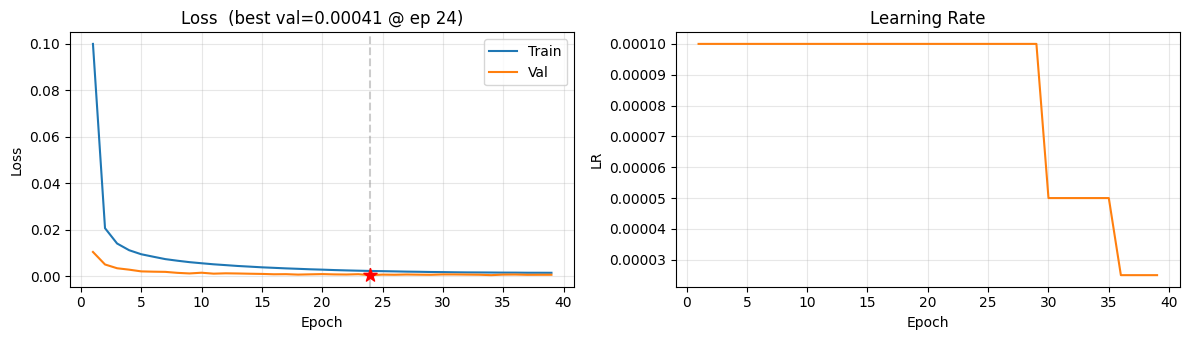

Epochs:  95%|█████████▌| 38/40 [02:00<00:06,  3.18s/ep, best=, lr=2.5e-05, train=0.00143, val=0.00058] 


Early stopping after epoch 40

Done — best val loss: 0.000411


In [5]:
trainer, history = train(
    model,
    train_loader,
    val_loader,
    epochs=40,
    lr=1e-4,
    patience=15,
    checkpoint_dir="../../checkpoints/dezem/lightweight",
)

In [6]:
history.display_table(last_n=10)

Epoch,Train Loss,Val Loss,LR,Time
30,0.001722,0.000722,5.00e-05,2.9s
31,0.001647,0.000713,5.00e-05,2.6s
32,0.001595,0.000651,5.00e-05,2.6s
33,0.001576,0.000599,5.00e-05,2.7s
34,0.001546,0.000418,5.00e-05,2.6s
35,0.001509,0.000647,5.00e-05,2.7s
36,0.001501,0.000679,2.50e-05,2.5s
37,0.001452,0.000560,2.50e-05,2.5s
38,0.001449,0.000575,2.50e-05,2.7s
39,0.001431,0.000581,2.50e-05,2.4s


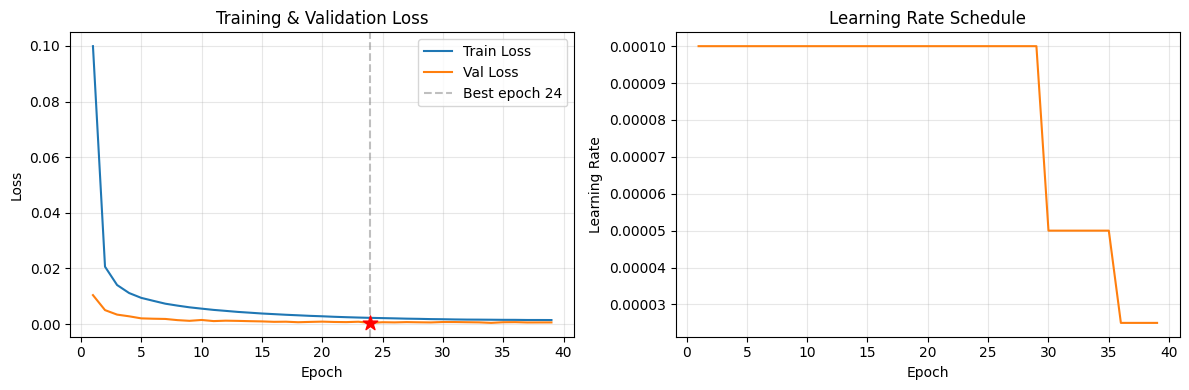

In [7]:
history.plot_learning_curves()

In [8]:
print(f"Best val loss: {trainer.best_val_loss:.6f}")
print(f"Checkpoint:    ../../checkpoints/smd/lightweight/best_model.pt")

Best val loss: 0.000411
Checkpoint:    ../../checkpoints/smd/lightweight/best_model.pt
